# 13. 초기 Log-Mel CNN

10초 Log-Mel 입력에서 CNN이 시간·주파수 패턴을 학습한 **2026-09-13 실험 기록**이다. 원곡 단위 split, Train 학습, Validation checkpoint·임계값 선택을 사용했다. 뒤의 13B·23번 공동 실험과 Test 수치를 한 실행으로 합치지 않는다.

In [3]:
import librosa

print("librosa:", librosa.__version__)

librosa: 1.0.0


In [4]:
from pathlib import Path
import json
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"

LOGMEL_DIR = PROJECT_ROOT / "data/processed/logmel"
LOGMEL_DIR.mkdir(parents=True, exist_ok=True)

LOGMEL_PATH = LOGMEL_DIR / "logmel_10s_float16.npy"
DONE_PATH = LOGMEL_DIR / "logmel_10s_done.npy"
INDEX_PATH = LOGMEL_DIR / "logmel_10s_index.csv"

RESULT_DIR = PROJECT_ROOT / "results/cnn"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/cnn"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

SR = 24_000
SEGMENT_SEC = 10.0
TARGET_SAMPLES = int(SR * SEGMENT_SEC)

N_FFT = 1024
HOP_LENGTH = 240
N_MELS = 128
FMAX = 12_000

# librosa center=True 기준
N_FRAMES = 1 + TARGET_SAMPLES // HOP_LENGTH

RANDOM_STATE = 42

print("SEGMENT_PATH :", SEGMENT_PATH)
print("LOGMEL_PATH  :", LOGMEL_PATH)
print("Shape target :", (N_MELS, N_FRAMES))

SEGMENT_PATH : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/metadata/segment_manifest_10s.csv
LOGMEL_PATH  : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/data/processed/logmel/logmel_10s_float16.npy
Shape target : (128, 1001)


## 1. PyTorch 확인 및 Device 선택

Mac에서는 Apple Silicon/MPS가 사용 가능하면 자동으로 MPS를 사용한다.

우선순위:

```text
CUDA → MPS → CPU
```

In [5]:
# PyTorch 확인 및 Device 선택
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
except ImportError:
    raise ImportError(
        "PyTorch가 설치되어 있지 않습니다. "
        "새 코드 셀에서 `%pip install torch`를 실행한 뒤 커널을 재시작하세요."
    )

print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

PyTorch version: 2.14.0
Device: mps


## 2. 재현성 설정

In [6]:
# 재현성 설정
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


## 3. Segment Manifest 로드

07단계에서 확정한 10,077개 segment를 사용한다.

In [7]:
segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)

print("===== SEGMENT MANIFEST =====")
print("Rows             :", len(segments))
print("Unique segment_id:", segments["segment_id"].nunique())
print("Tracks           :", segments["track_sample_id"].nunique())
print("Original groups  :", segments["original_audio"].nunique())

print("\nSplit:")
# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
print(segments["split"].value_counts())

print("\nLabel:")
print(segments["label"].value_counts())

assert len(segments) == 10077
assert segments["segment_id"].nunique() == 10077

===== SEGMENT MANIFEST =====
Rows             : 10077
Unique segment_id: 10077
Tracks           : 3458
Original groups  : 296

Split:
split
train    6967
test     1572
val      1538
Name: count, dtype: int64

Label:
label
FAKE    9189
REAL     888
Name: count, dtype: int64


# Part A. Log-Mel Spectrogram Cache

10,077개 segment에 대해 매 epoch마다 spectrogram을 다시 계산하면 매우 느리다.

따라서 처음 한 번만 Log-Mel을 계산하여 `float16` NumPy 파일로 저장하고,
CNN 학습에서는 이를 바로 읽는다.

예상 저장 용량은 약 **2.6 GB**이다.

중간에 중단되어도 `done` mask를 이용해 이어서 계산할 수 있다.

## 4. 10초 waveform 로딩 함수

In [8]:
# 10초 waveform 로딩 함수
def load_segment_waveform(row):
    full_path = PROJECT_ROOT / row["audio_path"]

    if not full_path.exists():
        raise FileNotFoundError(full_path)

    y, _ = librosa.load(
        full_path,
        sr=SR,
        mono=True,
        offset=float(row["start_sec"]),
        duration=SEGMENT_SEC,
    )

    y = np.asarray(y, dtype=np.float32)

    if len(y) < TARGET_SAMPLES:
        y = np.pad(
            y,
            (0, TARGET_SAMPLES - len(y)),
            mode="constant",
        )
    elif len(y) > TARGET_SAMPLES:
        y = y[:TARGET_SAMPLES]

    if len(y) != TARGET_SAMPLES:
        raise RuntimeError(f"waveform length mismatch: {len(y)}")

    return y

## 5. Log-Mel 변환 함수

각 segment에서:

```text
waveform
→ Mel Spectrogram
→ dB scale
→ [-80, 0] dB
→ [-1, 1] 범위로 정규화
```

이 정규화는 각 segment에 동일한 고정 수식을 적용하므로
Train / Val / Test 사이의 통계적 leakage가 발생하지 않는다.

In [9]:
def waveform_to_logmel(y):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=FMAX,
        power=2.0,
        center=True,
    )

    logmel = librosa.power_to_db(
        mel,
        ref=np.max,
        top_db=80.0,
    )

    # [-80, 0] → [-1, 1]
    logmel = (logmel + 40.0) / 40.0

    if logmel.shape != (N_MELS, N_FRAMES):
        raise RuntimeError(f"Unexpected logmel shape: {logmel.shape}")

    if not np.isfinite(logmel).all():
        raise ValueError("Log-Mel contains NaN or Inf")

    return logmel.astype(np.float32)

## 6. 첫 Segment 시험

전체 캐시를 만들기 전에 한 개만 확인한다.

In [10]:
# 첫 Segment 시험
test_row = segments.iloc[0]

test_y = load_segment_waveform(test_row)
test_logmel = waveform_to_logmel(test_y)

print("Waveform shape:", test_y.shape)
print("Log-Mel shape :", test_logmel.shape)
print("dtype         :", test_logmel.dtype)
print("min / max     :", test_logmel.min(), test_logmel.max())

Waveform shape: (240000,)
Log-Mel shape : (128, 1001)
dtype         : float32
min / max     : -1.0 1.0


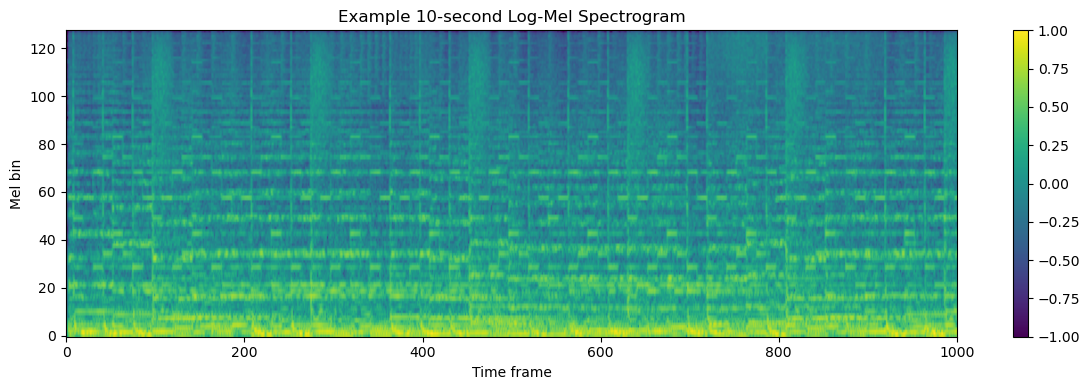

In [11]:
# 첫 Segment 시험
plt.figure(figsize=(12, 4))
plt.imshow(
    test_logmel,
    origin="lower",
    aspect="auto",
)
plt.title("Example 10-second Log-Mel Spectrogram")
plt.xlabel("Time frame")
plt.ylabel("Mel bin")
plt.colorbar()
plt.tight_layout()
plt.show()

## 7. Log-Mel Cache 초기화 / 재개

`logmel_10s_float16.npy`에는 spectrogram을 저장하고,
`logmel_10s_done.npy`에는 각 행의 계산 완료 여부를 저장한다.

In [12]:
EXPECTED_SHAPE = (
    len(segments),
    N_MELS,
    N_FRAMES,
)

if LOGMEL_PATH.exists():
    logmel_memmap = np.lib.format.open_memmap(
        LOGMEL_PATH,
        mode="r+",
    )

    if logmel_memmap.shape != EXPECTED_SHAPE:
        raise RuntimeError(
            f"Existing cache shape mismatch: "
            f"{logmel_memmap.shape} != {EXPECTED_SHAPE}"
        )
else:
    logmel_memmap = np.lib.format.open_memmap(
        LOGMEL_PATH,
        mode="w+",
        dtype=np.float16,
        shape=EXPECTED_SHAPE,
    )

if DONE_PATH.exists():
    # 배열 캐시를 읽어 저장된 특징과 ID의 순서를 확인한다.
    done_mask = np.load(DONE_PATH)

    if len(done_mask) != len(segments):
        raise RuntimeError("done mask length mismatch")
else:
    done_mask = np.zeros(
        len(segments),
        dtype=bool,
    )
    np.save(DONE_PATH, done_mask)

print("Cache shape  :", logmel_memmap.shape)
print("Completed    :", int(done_mask.sum()))
print("Remaining    :", int((~done_mask).sum()))

Cache shape  : (10077, 128, 1001)
Completed    : 0
Remaining    : 10077


## 8. 전체 Log-Mel Cache 생성

첫 실행에서 시간이 가장 오래 걸리는 부분이다.

100개마다 진행 상황과 done mask를 저장한다.
중단되면 같은 셀을 다시 실행하면 남은 segment부터 계속한다.

In [13]:
CACHE_SAVE_EVERY = 100

remaining_indices = np.where(~done_mask)[0]

start_time = time.time()

for n, idx in enumerate(remaining_indices, start=1):
    row = segments.iloc[idx]

    y = load_segment_waveform(row)
    logmel = waveform_to_logmel(y)

    logmel_memmap[idx] = logmel.astype(np.float16)
    done_mask[idx] = True

    if n % CACHE_SAVE_EVERY == 0 or n == len(remaining_indices):
        logmel_memmap.flush()
        np.save(DONE_PATH, done_mask)

        elapsed = time.time() - start_time

        print(
            f"this run: {n}/{len(remaining_indices)} | "
            f"total done: {int(done_mask.sum())}/{len(done_mask)} | "
            f"elapsed: {elapsed/60:.1f} min"
        )

np.save(DONE_PATH, done_mask)

segments[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "label",
        "label_id",
        "genre",
        "generator",
        "split",
    ]
].to_csv(
    INDEX_PATH,
    index=True,
    index_label="logmel_index",
    encoding="utf-8-sig",
)

print("\nLog-Mel cache complete:", bool(done_mask.all()))

this run: 100/10077 | total done: 100/10077 | elapsed: 0.0 min
this run: 200/10077 | total done: 200/10077 | elapsed: 0.1 min
this run: 300/10077 | total done: 300/10077 | elapsed: 0.1 min
this run: 400/10077 | total done: 400/10077 | elapsed: 0.2 min
this run: 500/10077 | total done: 500/10077 | elapsed: 0.2 min
this run: 600/10077 | total done: 600/10077 | elapsed: 0.2 min
this run: 700/10077 | total done: 700/10077 | elapsed: 0.3 min
this run: 800/10077 | total done: 800/10077 | elapsed: 0.3 min
this run: 900/10077 | total done: 900/10077 | elapsed: 0.4 min
this run: 1000/10077 | total done: 1000/10077 | elapsed: 0.4 min
this run: 1100/10077 | total done: 1100/10077 | elapsed: 0.4 min
this run: 1200/10077 | total done: 1200/10077 | elapsed: 0.5 min
this run: 1300/10077 | total done: 1300/10077 | elapsed: 0.5 min
this run: 1400/10077 | total done: 1400/10077 | elapsed: 0.6 min
this run: 1500/10077 | total done: 1500/10077 | elapsed: 0.6 min
this run: 1600/10077 | total done: 1600/100

## 9. Cache QC

In [14]:
# 배열 캐시를 읽어 저장된 특징과 ID의 순서를 확인한다.
done_mask = np.load(DONE_PATH)

print("Rows           :", len(done_mask))
print("Completed      :", int(done_mask.sum()))
print("Incomplete     :", int((~done_mask).sum()))
print("Cache shape    :", logmel_memmap.shape)
print("Cache dtype    :", logmel_memmap.dtype)

cache_qc_pass = (
    len(done_mask) == 10077
    and bool(done_mask.all())
    and logmel_memmap.shape == (10077, 128, N_FRAMES)
)

print("Log-Mel Cache QC PASS:", cache_qc_pass)

Rows           : 10077
Completed      : 10077
Incomplete     : 0
Cache shape    : (10077, 128, 1001)
Cache dtype    : float16
Log-Mel Cache QC PASS: True


# Part B. CNN Dataset / DataLoader

## 10. PyTorch Dataset

각 sample은:

```text
X: [1, 128, 1001]
y: 0(REAL) / 1(FAKE)
```

형태다.

In [15]:
class LogMelDataset(Dataset):
    def __init__(self, metadata, memmap_path):
        self.metadata = metadata.reset_index(drop=False).copy()
        self.memmap_path = memmap_path

        # 각 Dataset process에서 mmap을 직접 읽음
        self.data = np.load(
            self.memmap_path,
            mmap_mode="r",
        )

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]

        original_index = int(row["index"])

        x = np.asarray(
            self.data[original_index],
            dtype=np.float32,
        )

        x = torch.from_numpy(x.copy()).unsqueeze(0)

        y = torch.tensor(
            float(row["label_id"]),
            dtype=torch.float32,
        )

        return x, y, original_index


# 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
train_meta = segments[segments["split"] == "train"].copy()

val_meta = segments[segments["split"] == "val"].copy()

test_meta = segments[segments["split"] == "test"].copy()

train_ds = LogMelDataset(
    train_meta,
    LOGMEL_PATH,
)

val_ds = LogMelDataset(
    val_meta,
    LOGMEL_PATH,
)

test_ds = LogMelDataset(
    test_meta,
    LOGMEL_PATH,
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))

Train: 6967
Val  : 1538
Test : 1572


## 11. DataLoader

Mac/Jupyter 안정성을 위해 기본 `num_workers=0`을 사용한다.
MPS 메모리가 부족하면 `BATCH_SIZE`를 16으로 낮춘다.

In [16]:
# DataLoader
BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=False,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

xb, yb, idxb = next(iter(train_loader))

print("Batch X:", xb.shape)
print("Batch y:", yb.shape)

Batch X: torch.Size([32, 1, 128, 1001])
Batch y: torch.Size([32])


# Part C. Lightweight Log-Mel CNN

## 12. CNN 구조

4개의 convolution block을 사용한다.

```text
1 channel
→ 16
→ 32
→ 64
→ 128
→ Adaptive Average Pooling
→ Dropout
→ Binary Logit
```

파라미터 수는 2M보다 훨씬 작도록 제한한다.

In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_ch,
                out_ch,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class LogMelCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(1, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x.squeeze(1)


model = LogMelCNN().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print("\nTotal params    :", total_params)
print("Trainable params:", trainable_params)

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert total_params < 2_000_000

LogMelCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, mome

## 13. 클래스 불균형 가중치

FAKE가 약 91%, REAL이 약 9%이므로 그대로 BCE를 사용하면
다수 클래스인 FAKE에 지나치게 유리할 수 있다.

`FAKE = positive class`이므로:

```text
pos_weight
= Train REAL 수 / Train FAKE 수
```

를 사용하여 두 클래스의 총 loss 기여도를 비슷하게 맞춘다.

In [18]:
train_real = int((train_meta["label"] == "REAL").sum())

train_fake = int((train_meta["label"] == "FAKE").sum())

POS_WEIGHT = train_real / train_fake

print("Train REAL:", train_real)
print("Train FAKE:", train_fake)
print("pos_weight:", POS_WEIGHT)

# 클래스 불균형을 반영한 이진 분류 손실을 준비한다.
criterion = nn.BCEWithLogitsLoss(
    # 양성(FAKE) 손실 가중치는 해당 Train의 REAL/FAKE 수로 정한다.
    pos_weight=torch.tensor(
        [POS_WEIGHT],
        dtype=torch.float32,
        device=DEVICE,
    )
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

Train REAL: 621
Train FAKE: 6346
pos_weight: 0.09785691774346045


# Part D. Evaluation Functions

In [19]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)


# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
def find_eer_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(
        y_true,
        scores,
        pos_label=1,
    )

    fnr = 1.0 - tpr
    valid = np.isfinite(thresholds)

    fpr = fpr[valid]
    fnr = fnr[valid]
    thresholds = thresholds[valid]

    idx = np.argmin(np.abs(fpr - fnr))

    return {
        "eer": float((fpr[idx] + fnr[idx]) / 2.0),
        "threshold": float(thresholds[idx]),
        "fpr_at_eer": float(fpr[idx]),
        "fnr_at_eer": float(fnr[idx]),
    }


def evaluate_scores(
    y_true,
    scores,
    threshold,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )
    scores = np.asarray(
        scores,
        dtype=float,
    )

    y_pred = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
    eer_info = find_eer_threshold(y_true, scores)

    return {
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "eer": float(eer_info["eer"]),
        "threshold_used": float(threshold),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "real_fpr": float(fp / (fp + tn)),
        "fake_miss_rate": float(fn / (fn + tp)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def make_track_scores(
    metadata,
    scores,
):
    temp = metadata[
        [
            "track_sample_id",
            "original_audio",
            "label",
            "label_id",
            "genre",
            "generator",
            "split",
        ]
    ].copy()

    temp["score"] = scores

    return temp.groupby("track_sample_id", as_index=False).agg(
        original_audio=("original_audio", "first"),
        label=("label", "first"),
        label_id=("label_id", "first"),
        genre=("genre", "first"),
        generator=("generator", "first"),
        split=("split", "first"),
        segment_count=("score", "size"),
        score=("score", "mean"),
    )

## 14. Prediction 함수

In [20]:
@torch.no_grad()
def predict_loader(
    model,
    loader,
):
    model.eval()

    all_scores = []
    all_labels = []
    all_indices = []

    for x, y, original_idx in loader:
        x = x.to(DEVICE, non_blocking=False)

        # 현재 가중치로 입력의 FAKE logit을 계산한다.
        logits = model(x)

        scores = torch.sigmoid(logits).cpu().numpy()

        all_scores.append(scores)
        all_labels.append(y.numpy())
        all_indices.append(original_idx.numpy())

    return (
        np.concatenate(all_labels),
        np.concatenate(all_scores),
        np.concatenate(all_indices),
    )

# Part E. CNN Training

## 15. 학습 함수

Early stopping 기준은 **Validation Track-level EER**이다.

같은 곡의 여러 segment score를 평균한 뒤 계산한다.

In [21]:
MAX_EPOCHS = 20
PATIENCE = 4

BEST_MODEL_PATH = CHECKPOINT_DIR / "logmel_cnn_best.pt"

history_rows = []

best_val_track_eer = np.inf
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()

    model.train()

    running_loss = 0.0
    seen = 0

    for x, y, _ in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        # 이전 batch의 gradient를 지운다.
        optimizer.zero_grad()

        # Forward: Log-Mel batch를 FAKE logit으로 변환한다.
        logits = model(x)

        loss = criterion(logits, y)

        # Backward: 가중 BCE의 gradient를 계산한다.
        loss.backward()
        # Optimizer step: 계산한 gradient로 가중치를 갱신한다.
        optimizer.step()

        batch_size = x.size(0)

        running_loss += loss.item() * batch_size
        seen += batch_size

    train_loss = running_loss / seen

    # Validation
    val_y, val_scores, val_indices = predict_loader(model, val_loader)

    val_meta_ordered = segments.iloc[val_indices].reset_index(drop=True)

    # ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
    # EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
    val_segment_eer = find_eer_threshold(val_y, val_scores)

    val_track_df = make_track_scores(
        val_meta_ordered,
        val_scores,
    )

    val_track_eer = find_eer_threshold(
        val_track_df["label_id"],
        val_track_df["score"],
    )

    val_roc_auc = roc_auc_score(val_y, val_scores)

    elapsed = time.time() - epoch_start

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_segment_roc_auc": val_roc_auc,
            "val_segment_eer": val_segment_eer["eer"],
            "val_track_eer": val_track_eer["eer"],
            "elapsed_sec": elapsed,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"val seg AUC={val_roc_auc:.4f} | "
        f"val seg EER={val_segment_eer['eer']:.4f} | "
        f"val track EER={val_track_eer['eer']:.4f} | "
        f"{elapsed:.1f}s"
    )

    # Early stopping
    if val_track_eer["eer"] < best_val_track_eer - 1e-5:
        best_val_track_eer = val_track_eer["eer"]

        epochs_without_improvement = 0

        # 선택된 epoch의 가중치를 저장해 나중에 같은 모델을 복원한다.
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_val_track_eer": best_val_track_eer,
                "config": {
                    "sr": SR,
                    "segment_sec": SEGMENT_SEC,
                    "n_fft": N_FFT,
                    "hop_length": HOP_LENGTH,
                    "n_mels": N_MELS,
                    "fmax": FMAX,
                },
            },
            BEST_MODEL_PATH,
        )

        print("  -> saved best model")

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch " f"{epoch}")
            break

history = pd.DataFrame(history_rows)

history.to_csv(
    RESULT_DIR / "training_history.csv",
    index=False,
    encoding="utf-8-sig",
)

print("\nBest Validation Track EER:", best_val_track_eer)

Epoch 01 | loss=0.1018 | val seg AUC=0.7635 | val seg EER=0.3198 | val track EER=0.2461 | 82.1s
  -> saved best model
Epoch 02 | loss=0.0939 | val seg AUC=0.8012 | val seg EER=0.2810 | val track EER=0.1582 | 80.3s
  -> saved best model
Epoch 03 | loss=0.0879 | val seg AUC=0.7535 | val seg EER=0.3342 | val track EER=0.2689 | 79.6s
Epoch 04 | loss=0.0801 | val seg AUC=0.8514 | val seg EER=0.2215 | val track EER=0.2089 | 79.9s
Epoch 05 | loss=0.0715 | val seg AUC=0.8768 | val seg EER=0.2033 | val track EER=0.1324 | 78.9s
  -> saved best model
Epoch 06 | loss=0.0704 | val seg AUC=0.7958 | val seg EER=0.2765 | val track EER=0.2958 | 79.1s
Epoch 07 | loss=0.0625 | val seg AUC=0.9119 | val seg EER=0.1875 | val track EER=0.1241 | 78.9s
  -> saved best model
Epoch 08 | loss=0.0546 | val seg AUC=0.9298 | val seg EER=0.1354 | val track EER=0.0900 | 78.6s
  -> saved best model
Epoch 09 | loss=0.0508 | val seg AUC=0.9290 | val seg EER=0.1603 | val track EER=0.1075 | 79.2s
Epoch 10 | loss=0.0494 | v

## 16. 학습 곡선 확인

,epoch,train_loss,val_segment_roc_auc,val_segment_eer,val_track_eer,elapsed_sec
0,1,0.101807,0.763468,0.319831,0.246118,82.113359
1,2,0.093945,0.801225,0.280977,0.158220,80.330972
2,3,0.087895,0.753454,0.334163,0.268869,79.621042
3,4,0.080094,0.851443,0.221513,0.208898,79.918197
4,5,0.071540,0.876767,0.203268,0.132364,78.943344
5,6,0.070441,0.795816,0.276477,0.295760,79.067293
6,7,0.062471,0.911941,0.187513,0.124082,78.854861
7,8,0.054551,0.929771,0.135394,0.089968,78.603953
8,9,0.050822,0.929038,0.160271,0.107543,79.178056
9,10,0.049355,0.887533,0.197347,0.152009,79.203202


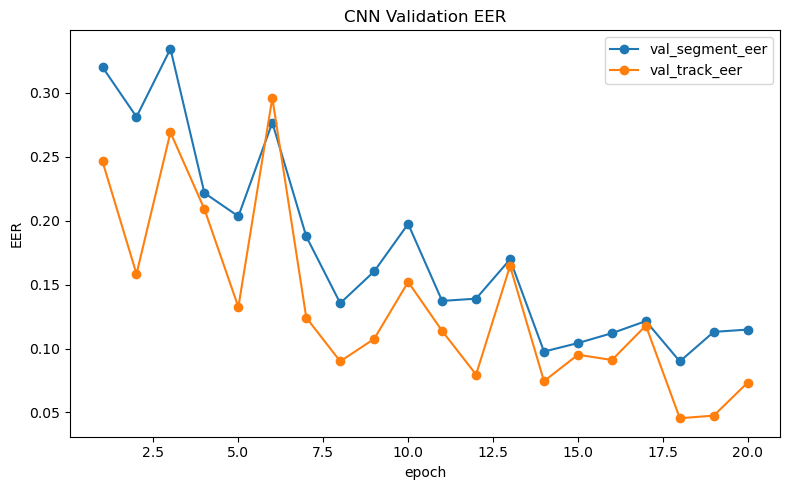

In [22]:
# 학습 곡선 확인
display(history)

ax = history.plot(
    x="epoch",
    y=[
        "val_segment_eer",
        "val_track_eer",
    ],
    marker="o",
    figsize=(8, 5),
    title="CNN Validation EER",
)

ax.set_ylabel("EER")
plt.tight_layout()
plt.show()

# Part F. Best Model Final Evaluation

## 17. Best checkpoint 로드

In [23]:
# Best checkpoint 로드
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
)

model.load_state_dict(checkpoint["model_state_dict"])

model.to(DEVICE)
model.eval()

print("Best epoch:", checkpoint["epoch"])

print("Best val track EER:", checkpoint["best_val_track_eer"])

Best epoch: 18
Best val track EER: 0.04550159984942594


## 18. Validation score와 threshold 결정

최종 best model에서:

- Segment-level threshold
- Track-level threshold

를 각각 Validation EER 기준으로 결정한다.

In [24]:
val_y, val_scores, val_indices = predict_loader(model, val_loader)

val_meta_ordered = segments.iloc[val_indices].reset_index(drop=True)

# ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
# EER은 두 오류율이 같아지는 지점이다. 분류에는 Validation에서 정한 임계값을 쓴다.
val_segment_eer = find_eer_threshold(val_y, val_scores)

val_track = make_track_scores(
    val_meta_ordered,
    val_scores,
)

val_track_eer = find_eer_threshold(
    val_track["label_id"],
    val_track["score"],
)

SEGMENT_THRESHOLD = val_segment_eer["threshold"]

TRACK_THRESHOLD = val_track_eer["threshold"]

print("===== VAL SEGMENT EER =====")
print(val_segment_eer)

print("\n===== VAL TRACK EER =====")
print(val_track_eer)

===== VAL SEGMENT EER =====
{'eer': 0.08990689253847149, 'threshold': 0.04316171258687973, 'fpr_at_eer': 0.09090909090909091, 'fnr_at_eer': 0.08890469416785207}

===== VAL TRACK EER =====
{'eer': 0.04550159984942594, 'threshold': 0.09354320168495178, 'fpr_at_eer': 0.045454545454545456, 'fnr_at_eer': 0.04554865424430643}


## 19. Test 평가

Test threshold는 다시 튜닝하지 않고
Validation에서 정한 값을 그대로 사용한다.

In [25]:
# Test 평가
test_y, test_scores, test_indices = predict_loader(model, test_loader)

test_meta_ordered = segments.iloc[test_indices].reset_index(drop=True)

test_segment_metrics = evaluate_scores(
    test_y,
    test_scores,
    SEGMENT_THRESHOLD,
)

test_track = make_track_scores(
    test_meta_ordered,
    test_scores,
)

test_track_metrics = evaluate_scores(
    test_track["label_id"],
    test_track["score"],
    TRACK_THRESHOLD,
)

val_segment_metrics = evaluate_scores(
    val_y,
    val_scores,
    SEGMENT_THRESHOLD,
)

val_track_metrics = evaluate_scores(
    val_track["label_id"],
    val_track["score"],
    TRACK_THRESHOLD,
)

cnn_results = pd.DataFrame(
    [
        {
            "model": "LogMelCNN",
            "level": "segment",
            "split": "val",
            **val_segment_metrics,
        },
        {
            "model": "LogMelCNN",
            "level": "segment",
            "split": "test",
            **test_segment_metrics,
        },
        {
            "model": "LogMelCNN",
            "level": "track",
            "split": "val",
            **val_track_metrics,
        },
        {
            "model": "LogMelCNN",
            "level": "track",
            "split": "test",
            **test_track_metrics,
        },
    ]
)

display(
    cnn_results[
        [
            "model",
            "level",
            "split",
            "roc_auc",
            "pr_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
            "threshold_used",
        ]
    ].round(4)
)

,model,level,split,roc_auc,pr_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,threshold_used
0,LogMelCNN,segment,val,0.9632,0.9963,0.0899,0.9101,0.7929,0.0909,0.0889,0.0432
1,LogMelCNN,segment,test,0.9520,0.9948,0.1349,0.8791,0.7795,0.1556,0.0863,0.0432
2,LogMelCNN,track,val,0.9882,0.9989,0.0455,0.9545,0.8762,0.0455,0.0455,0.0935
3,LogMelCNN,track,test,0.9772,0.9978,0.1042,0.9111,0.8535,0.1333,0.0445,0.0935


## 20. CNN Test confusion 정보

In [26]:
# CNN Test confusion 정보
print("===== SEGMENT TEST =====")
print(test_segment_metrics)

print("\n===== TRACK TEST =====")
print(test_track_metrics)

===== SEGMENT TEST =====
{'roc_auc': 0.9520296914868939, 'pr_auc': 0.9948056352773063, 'eer': 0.13486430062630478, 'threshold_used': 0.04316171258687973, 'balanced_accuracy': 0.87907678032939, 'macro_f1': 0.779466187040615, 'real_fpr': 0.15555555555555556, 'fake_miss_rate': 0.08629088378566457, 'tn': 114, 'fp': 21, 'fn': 124, 'tp': 1313}

===== TRACK TEST =====
{'roc_auc': 0.9772379667116509, 'pr_auc': 0.997756168921893, 'eer': 0.10416104363472783, 'threshold_used': 0.09354320168495178, 'balanced_accuracy': 0.9110661268556006, 'macro_f1': 0.8535212361208169, 'real_fpr': 0.13333333333333333, 'fake_miss_rate': 0.044534412955465584, 'tn': 39, 'fp': 6, 'fn': 22, 'tp': 472}


# Part G. RBF-SVM과 비교

## 21. 기존 baseline 결과와 비교

현재 가장 강했던 handcrafted baseline인
RBF-SVM과 CNN을 직접 비교한다.

In [27]:
BASELINE_METRICS_PATH = PROJECT_ROOT / "results/baseline/baseline_metrics.csv"

if BASELINE_METRICS_PATH.exists():
    baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH)

    svm_test = baseline_metrics[
        # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
        (baseline_metrics["model"] == "RBF-SVM") & (baseline_metrics["split"] == "test")
    ].copy()

    cnn_test = cnn_results[cnn_results["split"] == "test"].copy()

    comparison = pd.concat(
        [
            svm_test,
            cnn_test,
        ],
        ignore_index=True,
    )

    display(
        comparison[
            [
                "model",
                "level",
                "roc_auc",
                "eer",
                "balanced_accuracy",
                "macro_f1",
                "real_fpr",
                "fake_miss_rate",
            ]
        ].round(4)
    )
else:
    print("Baseline metrics not found:", BASELINE_METRICS_PATH)

,model,level,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
0,RBF-SVM,segment,0.9262,0.1475,0.8463,0.7115,0.1704,0.1371
1,RBF-SVM,track,0.9644,0.1395,0.8696,0.7502,0.1556,0.1053
2,LogMelCNN,segment,0.9520,0.1349,0.8791,0.7795,0.1556,0.0863
3,LogMelCNN,track,0.9772,0.1042,0.9111,0.8535,0.1333,0.0445


## 22. Test prediction 저장

이후 generator별 / genre별 / unseen / MP3 robustness 비교에 사용한다.

In [28]:
segment_predictions = test_meta_ordered[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "label",
        "label_id",
        "genre",
        "generator",
        "split",
    ]
].copy()

segment_predictions["cnn_score"] = test_scores

segment_predictions["cnn_pred"] = (test_scores >= SEGMENT_THRESHOLD).astype(int)

segment_predictions.to_csv(
    RESULT_DIR / "test_segment_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)


track_predictions = test_track.copy()

track_predictions["cnn_pred"] = (track_predictions["score"] >= TRACK_THRESHOLD).astype(
    int
)

track_predictions = track_predictions.rename(columns={"score": "cnn_score"})

track_predictions.to_csv(
    RESULT_DIR / "test_track_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Saved CNN predictions.")

Saved CNN predictions.


## 23. Metrics / Threshold 저장

In [29]:
cnn_results.to_csv(
    RESULT_DIR / "cnn_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

threshold_info = {
    "segment_eer_threshold": float(SEGMENT_THRESHOLD),
    "track_eer_threshold": float(TRACK_THRESHOLD),
    "segment_val_eer": float(val_segment_eer["eer"]),
    "track_val_eer": float(val_track_eer["eer"]),
    "best_epoch": int(checkpoint["epoch"]),
}

with open(
    RESULT_DIR / "cnn_thresholds.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        threshold_info,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("Saved metrics and thresholds.")

Saved metrics and thresholds.


## 24. 최종 CNN QC

In [30]:
# 최종 CNN QC
qc_summary = pd.DataFrame(
    {
        "check": [
            "segment_rows",
            "logmel_cache_complete",
            "train_segments",
            "val_segments",
            "test_segments",
            "model_params",
            "best_model_exists",
            "segment_threshold_finite",
            "track_threshold_finite",
            "test_track_rows",
            "result_rows",
        ],
        "value": [
            len(segments),
            bool(done_mask.all()),
            len(train_meta),
            len(val_meta),
            len(test_meta),
            total_params,
            BEST_MODEL_PATH.exists(),
            np.isfinite(SEGMENT_THRESHOLD),
            np.isfinite(TRACK_THRESHOLD),
            len(test_track),
            len(cnn_results),
        ],
    }
)

display(qc_summary)

cnn_qc_pass = (
    len(segments) == 10077
    and bool(done_mask.all())
    and len(train_meta) == 6967
    and len(val_meta) == 1538
    and len(test_meta) == 1572
    and total_params < 2_000_000
    and BEST_MODEL_PATH.exists()
    and np.isfinite(SEGMENT_THRESHOLD)
    and np.isfinite(TRACK_THRESHOLD)
    and len(test_track) == 539
    and len(cnn_results) == 4
)

print("===== FINAL RESULT =====")
print("CNN Core QC PASS:", cnn_qc_pass)

,check,value
0,segment_rows,10077
1,logmel_cache_complete,True
2,train_segments,6967
3,val_segments,1538
4,test_segments,1572
5,model_params,294321
6,best_model_exists,True
7,segment_threshold_finite,True
8,track_threshold_finite,True
9,test_track_rows,539


===== FINAL RESULT =====
CNN Core QC PASS: True


## 이어지는 기록

이 CNN의 초기 unseen·MP3 결과는 14·15번에 기록했다.

## 초기 CNN 결과

- Log-Mel CNN Test ROC-AUC는 Segment **0.9520**, Track **0.9772**다.
- Track EER은 **0.1042**, Balanced Accuracy는 **0.9111**, Macro-F1은 **0.8535**다.
- Best epoch는 18이며 Validation EER threshold를 Test에 고정 적용했다.
- Track aggregation은 segment-level보다 판별 성능을 높였다.
- 결과는 `results/cnn/`, checkpoint는 `checkpoints/cnn/`에 저장했다.